In [1]:
import sys, socket, os
from pathlib import Path
protected = [Path.cwd() / 'data', Path.cwd() / 'upstream']
def audit_raw_writes(event, args):
    if event == 'open' and isinstance(args[0], (str, bytes, os.PathLike)):
        path = Path(os.fsdecode(args[0])).resolve()
        mode, flags = args[1], args[2]
        write = (isinstance(mode, str) and any(c in mode for c in 'wax+')) or (isinstance(flags, int) and flags & (os.O_WRONLY | os.O_RDWR | os.O_CREAT | os.O_TRUNC))
        if write and any(path == p or path.is_relative_to(p) for p in protected):
            raise RuntimeError('Protected raw write attempted: ' + str(path))
def no_network(*args, **kwargs):
    raise RuntimeError('Network disabled for inspection verification')
sys.dont_write_bytecode = True
sys.addaudithook(audit_raw_writes)
socket.socket.connect = no_network
socket.create_connection = no_network


# データとtoken数の目視確認

最初のconfiguration cellを変更し、**Restart Kernel and Run All Cells** で上から実行してください。
既存のraw reader・inventory・preprocessing・token counterを呼ぶ閲覧用Notebookです。
data/の取得物、既存CSV、batch結果には書き込みません。OpenAI API・LLM評価・simulationは実行しません。

一覧は公式20 task＋外部5候補。Baiduは未取得、公式9 taskはrawのみで元promptは未対応です。
Notebookの保存出力は実行時の設定に対応するsnapshotなので、設定変更後は全セルを再実行してください。


In [2]:
DATASET = "MountainCar-v0"
EPISODE = 0
QUERY_INDEX = 10
HISTORY_SIZE = 1
HISTORY_SIZES = [0, 1, 2, 3, 5]

# None / None: 選択taskの既存LLM-X既定質問を使用。
# 指定する場合は両方変更。例: "next-action", "next_action_prediction"
METRIC = None
QUESTION_NAME = None
MODEL = "gpt-4o"

# 外部trajectory: SEQUENCE_IDとQUERY_INDEX。static: ROW_ID（全reader単位の通し番号）。
SEQUENCE_ID = None
ROW_ID = None

# 外部token表示は明示的に指定した場合だけ。Noneならraw inspectionのみ。
# 例: "configs/preprocessing/f16capstone_default.yaml"
PREPROCESSING_CONFIG = None
EXTERNAL_FULL_DATASET = False  # Trueで明示設定scope全体。既定は選択sequenceのみ。
MAX_EXTERNAL_QUERIES = 100_000 # 上限を超える計測は実行しない（sampleを全件に見せない）。

DATASET = 'aircombat_wez'
ROW_ID = 100
PREPROCESSING_CONFIG = 'configs/preprocessing/aircombat_wez_default.yaml'

In [3]:
from pathlib import Path
import sys
import json
import pandas as pd
from IPython.display import display, Markdown

# workspace直下／notebooks/のどちらから起動しても同じ既存moduleをimport。
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "dataset_adapters").is_dir() and (p / "configs/sources.json").is_file()), None)
if ROOT is None:
    raise RuntimeError("workspace直下またはnotebooks/から起動してください。")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from dataset_adapters.registry import get_adapter, EXTERNAL
from tools.notebook_inspection import (
    dataset_table, select_record, inspect_selected_file, preview_raw,
    preprocessing_for_inspection, selected_query, token_record,
    dataset_token_table, table_statistics, read_batch_summary,
)
from tools.count_input_tokens import resolve_encoding

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 20)
print("Workspace:", ROOT)
print("Read-only inspection. No API client or API request.")


Workspace: /Users/cls-lab/Git/Matsuo/mental-modeling-openai
Read-only inspection. No API client or API request.


## 1. 全dataset一覧

既存inventoryを使うlist_datasets.pyの共通処理から作成します。外部の固定state/action/reward shapeは未定義（null）で、欠損値を0にしません。外部record数は異種stream・duplicate export等を含むreader件数です。


In [4]:
datasets = dataset_table()
overview_columns = [
    "dataset_id", "category", "status", "files", "sequences", "records",
    "state_shape", "state_dtype", "action_shape", "action_dtype",
    "reward_shape", "reward_dtype", "sequential", "prompt_mode",
]
with pd.option_context("display.max_rows", None):
    display(datasets[overview_columns])
print(f"{len(datasets)} datasets; Baidu: NOT_ACQUIRED")


,dataset_id,category,status,files,sequences,records,state_shape,state_dtype,action_shape,action_dtype,reward_shape,reward_dtype,sequential,prompt_mode
0,Acrobot-v1,official,acquired,5,5.0,399.0,"[""T"", 1, 6]",float32,"[""T"", 1]",int64,"[""T"", 1]",float64,True,original_llmx
1,BipedalWalker-v3,official,acquired,2,2.0,144.0,"[""T"", 1, 24]",float32,"[""T"", 1, 4]",float32,"[""T"", 1]",float64,True,unsupported
2,CartPole-v1,official,acquired,5,5.0,2500.0,"[""T"", 1, 4]",float32,"[""T"", 1]",int64,"[""T"", 1]",float64,True,original_llmx
3,FetchPickAndPlace-v2,official,acquired,10,10.0,500.0,"[""T"", 1, 26]",float64,"[""T"", 1, 4]",float32,"[""T"", 1]",float32,True,original_llmx
4,FetchPush-v2,official,acquired,10,10.0,500.0,"[""T"", 1, 26]",float64,"[""T"", 1, 4]",float32,"[""T"", 1]",float32,True,original_llmx
5,FetchSlide-v2,official,acquired,10,10.0,500.0,"[""T"", 1, 26]",float64,"[""T"", 1, 4]",float32,"[""T"", 1]",float32,True,original_llmx
6,HalfCheetah-v4,official,acquired,3,3.0,3000.0,"[""T"", 1, 17]",float64,"[""T"", 1, 6]",float32,"[""T"", 1]",float64,True,unsupported
7,InvertedDoublePendulum-v4,official,acquired,10,10.0,538.0,"[""T"", 1, 11]",float64,"[""T"", 1, 1]",float32,"[""T"", 1]",float64,True,original_llmx
8,InvertedPendulum-v4,official,acquired,5,5.0,1419.0,"[""T"", 1, 4]",float64,"[""T"", 1, 1]",float32,"[""T"", 1]",float64,True,original_llmx
9,LunarLander-v2,official,acquired,3,3.0,744.0,"[""T"", 1, 8]",float32,"[""T"", 1]",int64,"[""T"", 1]",float64,True,original_llmx


25 datasets; Baidu: NOT_ACQUIRED


## 2. 選択datasetのschema — RAW DATA

選択元ファイルを既存inventoryコードで再読込し、保存済みinventoryのshape/dtypeと並べます。
shapeのsingleton次元を省略しません。CSVにはネイティブ数値dtypeがないため、schemaはinventory readerの型解釈、raw valueはreaderが保持した元の文字列として区別します。

TrajAirの配布元processed TXTは取得物の一部で、本projectがrawへ加工保存したものではありません。
F16のopaque MATLAB object・モデル等はraw adapter非対応のままです。


In [5]:
adapter = get_adapter(DATASET)
description = adapter.describe()
display(pd.DataFrame([
    {"item": "Dataset", "value": DATASET},
    {"item": "Source", "value": description["source"]},
    {"item": "Format", "value": description["format"]},
    {"item": "Files", "value": description["number_of_files"]},
    {"item": "Episodes / trajectories", "value": description["number_of_sequences"]},
    {"item": "Timesteps / rows (reader scope)", "value": description["number_of_records"]},
]))
sequence, raw_record = select_record(
    adapter, episode=EPISODE, sequence_id=SEQUENCE_ID, row_id=ROW_ID, index=QUERY_INDEX
)
schema_table = pd.DataFrame()
if sequence is None:
    print("NOT_ACQUIRED: raw data inspection unavailable.")
else:
    print("Source file:", sequence.source_file)
    print("Sequence:", sequence.sequence_id, "key:", sequence.key)
    print("Selected reader-unit records:", sequence.length)
    schema_table, file_counts, actual_schema = inspect_selected_file(adapter, sequence)
    print("Actual file read vs saved inventory (file-level schema):")
    with pd.option_context("display.max_rows", None):
        display(schema_table)
    display(file_counts)
    if description.get("unreadable_variables"):
        print("Opaque MATLAB variables are inventory-only; not converted to trajectories.")
        display(pd.DataFrame(description["unreadable_variables"])[["source_file", "variable", "reason"]])


,item,value
0,Dataset,aircombat_wez
1,Source,{'commit': '5ae42f4e56362e4df2bf29c5c01cbfb50c...
2,Format,"[.csv, .ipynb, .md, .py, .txt, no_extension]"
3,Files,17
4,Episodes / trajectories,None
5,Timesteps / rows (reader scope),4050


Source file: data/candidate_datasets/aircombat_wez/repository/Data/FactorialExperiment.csv
Sequence: 0 key: repository/Data/FactorialExperiment.csv
Selected reader-unit records: 864
Actual file read vs saved inventory (file-level schema):


,name,shape,dtype,ndim,shape_inventory,dtype_inventory,ndim_inventory,matches_inventory
0,BL_Alt,[864],float64,1,[864],float64,1,True
1,BL_Hdg,[864],int64,1,[864],int64,1,True
2,BL_Speed,[864],int64,1,[864],int64,1,True
3,Case,[864],int64,1,[864],int64,1,True
4,RD_Alt,[864],float64,1,[864],float64,1,True
5,RD_Hdg,[864],int64,1,[864],int64,1,True
6,RD_Speed,[864],int64,1,[864],int64,1,True
7,maxRange,[864],float64,1,[864],float64,1,True
8,minErrorTry,[864],float64,1,[864],float64,1,True
9,rad,[864],int64,1,[864],int64,1,True


,measure,actual,inventory,matches
0,rows,864,864,True
1,columns,10,10,True


## 3. 実際のraw value — RAW DATA

先頭5 recordと指定番号を表示します。公式はstates[:5] / actions[:5] / rewards[:5]を含む全arrayを表示。
episodic_returnはepisode全体の値として別扱いです。外部では元columnをそのまま表示し、state/action/rewardへ変換しません。

外部の別ファイルを選ぶには `adapter.sequences()` のsequence_idをconfigurationへ設定できます。


In [6]:
raw_preview = None
if sequence is not None:
    raw_preview = preview_raw(adapter, sequence, count=5)
    if isinstance(raw_preview, dict):
        for name, values in raw_preview.items():
            print(f"\n{name} (episode scope)" if name == "episodic_return" else f"\n{name}[:5]")
            print(values)
    else:
        display(raw_preview)
    print("\nSELECTED RAW RECORD")
    print("episode =", raw_record["episode_id"], "sequence =", raw_record["sequence_id"],
          "row =", raw_record.get("row_id"), "index =", raw_record["index"])
    print("Source:", raw_record["source_file"])
    print("SHA256:", raw_record["source_file_sha256"])
    # JSON表示なので指定recordの値をDataFrameの省略表示に隠しません。
    print(json.dumps(raw_record["fields"], ensure_ascii=False, indent=2))
else:
    print("Raw value: N/A (not acquired)")


,index,Case,BL_Speed,RD_Speed,rad,BL_Hdg,RD_Hdg,BL_Alt,RD_Alt,maxRange,minErrorTry
0,0,0,450,450,0,0,180,304.8,1828.8,22.1484375,22.32421875
1,1,1,600,450,0,0,180,304.8,1828.8,23.203125,23.37890625
2,2,2,750,450,0,0,180,304.8,1828.8,21.796875,21.97265625
3,3,3,450,600,0,0,180,304.8,1828.8,25.3125,25.48828125
4,4,4,600,600,0,0,180,304.8,1828.8,26.71875,26.89453125



SELECTED RAW RECORD
episode = None sequence = 0 row = 100 index = 100
Source: data/candidate_datasets/aircombat_wez/repository/Data/FactorialExperiment.csv
SHA256: b02b5571bfab987a83909175aac54adccadb8d5caa4c831be5fbd29cca2a9a78
{
  "Case": {
    "value": "100",
    "dtype": "<U3",
    "shape": []
  },
  "BL_Speed": {
    "value": "600",
    "dtype": "<U3",
    "shape": []
  },
  "RD_Speed": {
    "value": "450",
    "dtype": "<U3",
    "shape": []
  },
  "rad": {
    "value": "-60",
    "dtype": "<U3",
    "shape": []
  },
  "BL_Hdg": {
    "value": "0",
    "dtype": "<U1",
    "shape": []
  },
  "RD_Hdg": {
    "value": "120",
    "dtype": "<U3",
    "shape": []
  },
  "BL_Alt": {
    "value": "304.8",
    "dtype": "<U5",
    "shape": []
  },
  "RD_Alt": {
    "value": "304.8",
    "dtype": "<U5",
    "shape": []
  },
  "maxRange": {
    "value": "19.86328125",
    "dtype": "<U11",
    "shape": []
  },
  "minErrorTry": {
    "value": "20.0390625",
    "dtype": "<U10",
    "shape": [

## 4. MODEL INPUT AFTER PREPROCESSING

ここからraw表示とは別です。公式対応taskはpreprocessing/llmx_original.pyを通し、元の
Episode / history_text / render_question / system_prompt / user_promptをそのまま使います。
未対応taskのpromptは作りません。

外部はPREPROCESSING_CONFIGを明示した場合だけ、その既存baselineを使います。
このpreprocessingはraw datasetそのものではなく、本projectで定義したLLM入力用変換です。
staticはH=0のみ。存在しないaction/rewardを生成しません。


In [7]:
config, preprocessing_status = preprocessing_for_inspection(DATASET, PREPROCESSING_CONFIG)
print("Raw data inspection:", "available" if sequence is not None else "unavailable")
print(preprocessing_status)
query = None
if config is not None and sequence is not None:
    display(config)
    try:
        query = selected_query(adapter, sequence, raw_record["index"], config,
                               HISTORY_SIZE, METRIC, QUESTION_NAME)
    except (ValueError, IndexError) as exc:
        print("Selected model input: N/A —", exc)
    if query is not None:
        print("Prompt mode:", config["prompt_mode"])
        print("Metric / question:", query.metric, "/", query.question_name)
        print("Effective history size:", query.history_size)
        print("History interval [start, end):", query.history_start, query.history_end)
        print("\nHISTORY REPRESENTATION\n")
        print(query.history_text)
else:
    print("Token count: N/A")


Raw data inspection: available
Model-input preprocessing: defined


{'name': 'aircombat_wez_example_baseline',
 'dataset_id': 'aircombat_wez',
 'prompt_mode': 'external_static',
 'source_globs': ['data/candidate_datasets/aircombat_wez/*/Data/*.csv'],
 'fields': '*',
 'state_columns': [],
 'action_columns': [],
 'reward_column': None,
 'value_format': 'lexical',
 'system_prompt': 'Describe the supplied static scenario and target fields. They are not a trajectory, action, or reward sequence.',
 'question': 'Summarize this scenario and its recorded targets; do not infer missing actions or rewards.'}

Prompt mode: external_static
Metric / question: representation / baseline_description
Effective history size: 0
History interval [start, end): 100 101

HISTORY REPRESENTATION

Record:
{
  "fields": {
    "BL_Alt": "304.8",
    "BL_Hdg": "0",
    "BL_Speed": "600",
    "Case": "100",
    "RD_Alt": "304.8",
    "RD_Hdg": "120",
    "RD_Speed": "450",
    "maxRange": "19.86328125",
    "minErrorTry": "20.0390625",
    "rad": "-60"
  }
}


## 5. 実際のprompt全文

以下が実際のSYSTEM PROMPTとUSER PROMPTです。外部設定時は元LLM-Xではなくexternal baselineと表示します。文字列を組み立てるだけで送信はしません。


In [8]:
if query is not None:
    print("Original LLM-X" if config["prompt_mode"] == "original_llmx" else "EXTERNAL BASELINE")
    print("\nSYSTEM PROMPT\n")
    print(query.system_prompt)
    print("\nUSER PROMPT\n")
    print(query.user_prompt)
else:
    print("Prompt: N/A")


EXTERNAL BASELINE

SYSTEM PROMPT

Describe the supplied static scenario and target fields. They are not a trajectory, action, or reward sequence.

USER PROMPT

Record:
{
  "fields": {
    "BL_Alt": "304.8",
    "BL_Hdg": "0",
    "BL_Speed": "600",
    "Case": "100",
    "RD_Alt": "304.8",
    "RD_Hdg": "120",
    "RD_Speed": "450",
    "maxRange": "19.86328125",
    "minErrorTry": "20.0390625",
    "rad": "-60"
  }
}

Summarize this scenario and its recorded targets; do not infer missing actions or rewards.


## 6. 選択queryのtoken数

既存count_input_tokens.count_queryを使用。contentは実文字列のlocal tokenize結果です。
estimated_api_input_tokensは既存CLIと同じcontent + 2×3 + 3の概算で、server usageではありません。
history/questionを別々にtokenizeした値はBPE境界のためuser_tokensへ単純加算できません。
未知のmodel名ではfallbackを明示します。tokenizer未キャッシュ時だけ公開tokenizer assetの取得が必要になる場合があります（inference APIではありません）。


In [9]:
selected_tokens = None
if query is not None:
    encoding, fallback_used = resolve_encoding(MODEL)
    print("Model:", MODEL, "\nTokenizer:", encoding.name)
    print("Fallback tokenizer:", fallback_used)
    if fallback_used:
        print("WARNING: unknown model; fallback tokenizer is being used.")
    selected_tokens = token_record(query, sequence, config, encoding, fallback_used, MODEL)
    token_columns = ["system_tokens", "history_tokens", "question_tokens", "user_tokens",
                     "total_content_tokens", "estimated_api_input_tokens"]
    display(pd.DataFrame([{"component": key, "tokens": selected_tokens[key]} for key in token_columns]))
    print("Preprocessing SHA256:", selected_tokens["preprocessing_config_sha256"])
else:
    print("Token count: N/A")


Model: gpt-4o 
Tokenizer: o200k_base
Fallback tokenizer: False


,component,tokens
0,system_tokens,21
1,history_tokens,108
2,question_tokens,18
3,user_tokens,126
4,total_content_tokens,147
5,estimated_api_input_tokens,156


Preprocessing SHA256: 72ea28a57e92d6cbb7ec3226e3084d2177924883949969a90d1ce55d9d23d960


## 7. データ番号ごとのtoken数

公式は選択datasetの**全episode・全valid query**を、現在のH / metric / questionで再計測します。
全行はquery_tokens DataFrameに保持し、長い表の画面表示は先頭・末尾に省略されます。
外部は既定で選択sequenceのみ。全設定scopeはEXTERNAL_FULL_DATASET=Trueで明示し、MAX_EXTERNAL_QUERIESを超えた場合は実行しません。自動samplingはしません。


In [10]:
query_tokens, count_scope = dataset_token_table(
    adapter, config, HISTORY_SIZE, MODEL, METRIC, QUESTION_NAME,
    external_sequence=sequence.sequence_id if sequence else None,
    external_full_dataset=EXTERNAL_FULL_DATASET,
    max_external_queries=MAX_EXTERNAL_QUERIES,
)
print("Scope:", count_scope)
print("Computed query rows:", len(query_tokens))
query_columns = ["episode_id", "sequence_id", "query_index", "history_start", "history_end",
                 "input_tokens", "source_file"]
if not query_tokens.empty:
    display(query_tokens[query_columns])
    if query_tokens["fallback_encoding_used"].any():
        print("WARNING: fallback tokenizer used:", query_tokens["tokenizer"].unique())


Scope: selected external reader unit only (not whole dataset)
Computed query rows: 864


,episode_id,sequence_id,query_index,history_start,history_end,input_tokens,source_file
0,None,0,0,0,1,157,data/candidate_datasets/aircombat_wez/reposito...
1,None,0,1,1,2,156,data/candidate_datasets/aircombat_wez/reposito...
2,None,0,2,2,3,156,data/candidate_datasets/aircombat_wez/reposito...
3,None,0,3,3,4,156,data/candidate_datasets/aircombat_wez/reposito...
4,None,0,4,4,5,156,data/candidate_datasets/aircombat_wez/reposito...
...,...,...,...,...,...,...,...
859,None,0,859,859,860,157,data/candidate_datasets/aircombat_wez/reposito...
860,None,0,860,860,861,157,data/candidate_datasets/aircombat_wez/reposito...
861,None,0,861,861,862,157,data/candidate_datasets/aircombat_wez/reposito...
862,None,0,862,862,863,158,data/candidate_datasets/aircombat_wez/reposito...


## 8. token統計・上位5件／下位5件

既存token_statisticsを利用。stdは母標準偏差(ddof=0)、p95はnearest-rankです。
input_tokensは上記のAPI入力概算を指します。


In [11]:
statistics_table = pd.DataFrame()
if not query_tokens.empty:
    statistics_table = pd.DataFrame([table_statistics(query_tokens)])
    display(statistics_table)
    print("Largest 5 queries")
    display(query_tokens.nlargest(5, "input_tokens")[query_columns])
    print("Smallest 5 queries")
    display(query_tokens.nsmallest(5, "input_tokens")[query_columns])
else:
    print("Statistics: N/A")


,number_of_queries,mean,std,min,max,median,p95,total_input_tokens
0,864,156.924769,1.110821,153,158,157.0,158,135583


Largest 5 queries


,episode_id,sequence_id,query_index,history_start,history_end,input_tokens,source_file
27,None,0,27,27,28,158,data/candidate_datasets/aircombat_wez/reposito...
31,None,0,31,31,32,158,data/candidate_datasets/aircombat_wez/reposito...
32,None,0,32,32,33,158,data/candidate_datasets/aircombat_wez/reposito...
33,None,0,33,33,34,158,data/candidate_datasets/aircombat_wez/reposito...
36,None,0,36,36,37,158,data/candidate_datasets/aircombat_wez/reposito...


Smallest 5 queries


,episode_id,sequence_id,query_index,history_start,history_end,input_tokens,source_file
519,None,0,519,519,520,153,data/candidate_datasets/aircombat_wez/reposito...
96,None,0,96,96,97,154,data/candidate_datasets/aircombat_wez/reposito...
298,None,0,298,298,299,154,data/candidate_datasets/aircombat_wez/reposito...
308,None,0,308,308,309,154,data/candidate_datasets/aircombat_wez/reposito...
432,None,0,432,432,433,154,data/candidate_datasets/aircombat_wez/reposito...


## 9. token分布

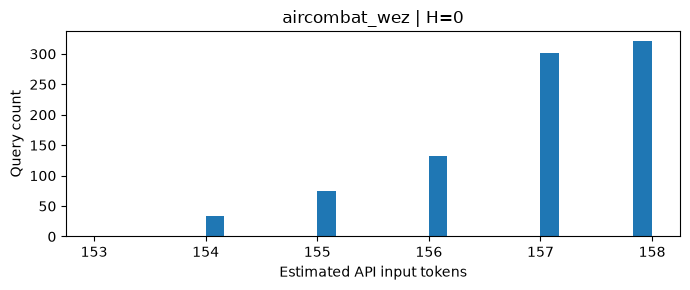

In [12]:
if not query_tokens.empty:
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(7, 3))
    ax.hist(query_tokens["input_tokens"], bins=30)
    ax.set_xlabel("Estimated API input tokens")
    ax.set_ylabel("Query count")
    ax.set_title(f"{DATASET} | H={query_tokens['history_size'].iloc[0]}")
    fig.tight_layout()
    plt.show()
else:
    print("Histogram: N/A")


## 10. history size比較

選択datasetに対してのみ計算します。各Hで有効query集合が変わるため、totalの差と同一queryの増加は別です。
各Hの全行はhistory_tables[H]に保持します。比較にはepisode_id / sequence_id / query_indexでjoinできます。
外部staticはH=0のみ表示します。


In [13]:
history_tables = {}
history_rows = []
if config is not None:
    hs = [0] if config["prompt_mode"] == "external_static" else sorted(set(HISTORY_SIZES))
    for h in hs:
        current_h = 0 if config["prompt_mode"] == "external_static" else HISTORY_SIZE
        if h == current_h:
            table, scope = query_tokens, count_scope
        else:
            table, scope = dataset_token_table(
                adapter, config, h, MODEL, METRIC, QUESTION_NAME,
                external_sequence=sequence.sequence_id if sequence else None,
                external_full_dataset=EXTERNAL_FULL_DATASET,
                max_external_queries=MAX_EXTERNAL_QUERIES,
            )
        history_tables[h] = table
        if table.empty:
            print(f"H={h}: no queries — {scope}")
            continue
        history_rows.append({"history_size": h, **table_statistics(table), "scope": scope})
history_comparison = pd.DataFrame(history_rows)
display(history_comparison if not history_comparison.empty else "History comparison: N/A")


,history_size,number_of_queries,mean,std,min,max,median,p95,total_input_tokens,scope
0,0,864,156.924769,1.110821,153,158,157.0,158,135583,selected external reader unit only (not whole ...


## 11. 保存済み全dataset token summary

outputs/token_counts/token_inventory.csvがあれば読み込むだけです。model/tokenizerの保存時情報も表示します。
**この表は現在のconfigurationで再計算した結果ではありません。**
prompt_mode・H・config SHA・全件/sample scopeを維持し、混ぜて合計しません。
CSVがなければbatchを起動せずメッセージだけ表示します。


In [14]:
batch_summary = read_batch_summary()
if batch_summary is None:
    print("Token batch has not been executed yet.")
else:
    metadata_path = ROOT / "outputs/token_counts/summary.json"
    if metadata_path.is_file():
        metadata = json.loads(metadata_path.read_text())
        print("Saved batch model:", metadata.get("model"), "tokenizer:", metadata.get("tokenizer"))
    batch_columns = [
        "dataset", "n_units", "prompt_mode", "history_size", "count_scope",
        "mean_input_tokens", "std_input_tokens", "min_input_tokens", "max_input_tokens",
        "p95_input_tokens", "total_input_tokens", "preprocessing_config_sha256",
    ]
    with pd.option_context("display.max_rows", None):
        display(batch_summary[[c for c in batch_columns if c in batch_summary]])
    print("No batch was started. Existing results were read only.")


Saved batch model: gpt-4o tokenizer: o200k_base


,dataset,n_units,prompt_mode,history_size,count_scope,mean_input_tokens,std_input_tokens,min_input_tokens,max_input_tokens,p95_input_tokens,total_input_tokens,preprocessing_config_sha256
0,Acrobot-v1,394,original_llmx,0,full_selected_scope,829.604061,2.687739,824,851,832,326864,93dfa8c41a457a02bc85c81dcf71a31bf96226ea544bc7...
1,Acrobot-v1,389,original_llmx,1,full_selected_scope,887.868895,3.258492,880,910,890,345381,08dcac0bdc5397de4bf8cc6a1df8833e2094350602bf0b...
2,Acrobot-v1,384,original_llmx,2,full_selected_scope,946.148438,3.760589,938,969,949,363321,e65b1fd900a1a9f5fc12e4409906252cebd7498879e226...
3,Acrobot-v1,379,original_llmx,3,full_selected_scope,1004.432718,4.279495,996,1028,1008,380680,c0c4a33cf5f4d0c0bc4f4b7d57e8227c90e984b61cce88...
4,Acrobot-v1,369,original_llmx,5,full_selected_scope,1120.978320,5.256517,1112,1146,1126,413641,8f9e90a0f3fdba34c0f15aa6a4ae696fa21b4db2805e19...
5,Acrobot-v1,344,original_llmx,10,full_selected_scope,1412.287791,7.274220,1400,1438,1429,485827,aa547e15a1fa5f9d58e077cd5bc5b80fa8ddc06e53de3a...
6,CartPole-v1,2495,original_llmx,0,full_selected_scope,785.440080,2.056203,781,799,787,1959673,93dfa8c41a457a02bc85c81dcf71a31bf96226ea544bc7...
7,CartPole-v1,2490,original_llmx,1,full_selected_scope,830.610040,2.619846,825,845,833,2068219,08dcac0bdc5397de4bf8cc6a1df8833e2094350602bf0b...
8,CartPole-v1,2485,original_llmx,2,full_selected_scope,875.781087,3.118770,868,891,879,2176316,e65b1fd900a1a9f5fc12e4409906252cebd7498879e226...
9,CartPole-v1,2480,original_llmx,3,full_selected_scope,920.946774,3.566928,912,936,925,2283948,c0c4a33cf5f4d0c0bc4f4b7d57e8227c90e984b61cce88...


No batch was started. Existing results were read only.


### 処理の所在

- 一覧: tools/list_datasets.py、保存済みoutputs/dataset_inventory/
- raw読込: dataset_adapters/、再照合: tools/inventory_llmx_data.py / inventory_candidates.py
- prompt: preprocessing/llmx_original.py / prompting.py（Notebook内では再実装しない）
- local token / 統計: tools/count_input_tokens.py
- 閲覧用の表への整形: tools/notebook_inspection.py

参考: [OpenAI GPT-4o](https://developers.openai.com/api/docs/models/gpt-4o)、[Text generation](https://developers.openai.com/api/docs/guides/text)。
ここではモデル推論もAPI呼び出しも行っていません。


In [15]:
assert raw_record['row_id'] == 100
assert query.history_size == 0
assert selected_tokens['prompt_mode'] == 'external_static'
assert len(history_comparison) == 1
assert set(history_tables) == {0}
assert len(query_tokens) == sequence.length
assert 'selected external reader unit only' in count_scope
print('Explicit external preprocessing assertions passed')

Explicit external preprocessing assertions passed
